In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bosperrus import FIT_PALETTE, plot_fit
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Everything below reads precomputed per-sample results -- written on a compute
# node by src/utils/st_precompute.py (see st_precompute.sbatch), which runs
# bosperrus.load_filtered + identify_analysis_buffer_from_filtered (+ BLADE) and
# bosperrus.quantify_diffusion_from_raw at 8um for every sample in st_samples.csv.
RESULTS_DIR = Path("../results/exploratory/st_reroll")
SAMPLES = pd.read_csv("../src/utils/st_samples.csv")


In [2]:
DATASET_TYPE_MARKERS = {"visium_demo": "o", "visium_custom": "s", "stomics_custom": "^", "Visium HD": "s", "STOmics": "^"}

In [3]:
PATIENT_PAIRS = [
    ("Pat1", "A02991D1"), ("Pat2", "A02994C6"), ("Pat3", "Y01087DD"), ("Pat4", "Y01084J8"),
]

# Part 1: Visium HD Demo (spot-based border)

In [4]:
results = []

In [5]:
def _nan(v):
    return np.nan if v is None else v  # JSON null (e.g. ConstantFit won / BLADE never reached p >= 0.05)

for sample in SAMPLES["name"]:
    buf = json.loads((RESULTS_DIR / f"{sample}_buffer.json").read_text())
    bin_size_um = buf["resolution_um"]
    print(f"{sample}: {len(buf['per_component'])} component(s) > {buf['min_component_size']} bins")

    for label, info in buf["per_component"].items():
        # bsp_thresh_um: piecewise_linear_b, already in um; bsp_thresh: the same in grid steps
        bsp_thresh_um = _nan(info["bsp_thresh_um"])
        results.append([
            sample, int(label), f"{sample}_{label}", info["n_spots"],
            _nan(info["blade_thresh"]), bsp_thresh_um / bin_size_um, _nan(info["blade_thresh_corrected"]),
            bin_size_um,
            _nan(info["blade_thresh_um"]), bsp_thresh_um, _nan(info["blade_thresh_corrected_um"]),
            info["pct_affected"],
        ])


breast_cancer: 3 component(s) > 1000 bins
pancreas: 1 component(s) > 1000 bins
colon_cancer_ff: 1 component(s) > 1000 bins
breast_cancer_tma: 36 component(s) > 1000 bins
Pat1: 1 component(s) > 1000 bins
Pat2: 3 component(s) > 1000 bins
Pat3: 4 component(s) > 1000 bins
Pat4: 2 component(s) > 1000 bins
A02991D1: 1 component(s) > 1000 bins
A02994C6: 5 component(s) > 1000 bins
Y01087DD: 6 component(s) > 1000 bins
Y01084J8: 5 component(s) > 1000 bins


In [6]:
results_df = pd.DataFrame(results, columns=[
    "sample", "component_rank", "component_label", "component_size",
    "blade_thresh", "bsp_thresh", "blade_thresh_corrected",
    "bin_size_um", "blade_thresh_um", "bsp_thresh_um", "blade_thresh_corrected_um",
    "pct_affected",
])
results_df = results_df.merge(SAMPLES[["name", "dataset_type"]], left_on="sample", right_on="name")
counts = results_df["sample"].value_counts()
results_df["num_components"] = results_df["sample"].apply(lambda x: counts[x])
results_df["component_size_um"] = results_df["component_size"] * results_df["bin_size_um"] ** 2  # bin count -> physical area (um^2)

In [7]:
demo_results_df = results_df[results_df["dataset_type"] == "visium_demo"]

In [8]:
sample_pal = dict()
pair_colors = sns.color_palette("Paired", 9)
results_df["pair"] = None

for (i, pair) in enumerate(PATIENT_PAIRS):
    sample_pal[pair[0]] = pair_colors[2 * i]
    sample_pal[pair[1]] = pair_colors[2 * i + 1]
    mask = results_df["sample"].isin(pair)
    results_df.loc[mask, "pair"] = "_".join(pair)

sample_pal.update({s: sns.color_palette("Purples", 4)[i] for (i, s) in enumerate(demo_results_df["sample"].unique())})

# Part 2: paired Custom Visium HD + STOmics (no component matching -- see `notebooks/exploratory/stomics_visium_phase_matching.ipynb` for why)

In [9]:
part2_df = results_df[results_df["dataset_type"].isin(["visium_custom", "stomics_custom"])].copy()
part2_df["technology"] = part2_df["dataset_type"].map({"visium_custom": "Visium HD", "stomics_custom": "STOmics"})

In [10]:
figure2_df = demo_results_df.sort_values(["dataset_type", "sample", "component_rank"]).reset_index(drop=True)
component_spacing = 1
sample_gap = 2

x_pos = []
x = 0
previous_sample = None

for _, row in figure2_df.iterrows():
    if previous_sample is not None:
        x += sample_gap if row["sample"] != previous_sample else component_spacing
    x_pos.append(x)
    previous_sample = row["sample"]

x_pos = np.array(x_pos)
figure2_df["x_pos"] = x_pos

# Part 3: RNA diffusion outside the image mask

Pooled, component-free fits on RAW (whole-capture-area, zero-count bins included)
data at 8um for both technologies, via `bosperrus.quantify_diffusion_from_raw`
(computed on a compute node by `src/utils/st_precompute.py`). Masks are
image-only: `segment_tissue_from_rgb` on the Visium hires H&E, and
`segment_tissue_from_ssdna` on the STOmics ssDNA (multi-Otsu for A02991D1,
single Otsu otherwise -- see `src/utils/st_samples.csv`).


In [11]:
raw_pooled_df = pd.DataFrame([
    json.loads((RESULTS_DIR / f"{sample}_diffusion_8um.json").read_text()) for sample in SAMPLES["name"]
])

PATIENT_PAIR_LOOKUP = {s: "_".join(pair) for pair in PATIENT_PAIRS for s in pair}
raw_pooled_df["pair"] = raw_pooled_df["sample"].map(PATIENT_PAIR_LOOKUP)  # NaN for demo samples
raw_pooled_df["perc_outside"] = raw_pooled_df["perc_counts_outside"]  # counts-weighted
raw_pooled_df["1/beta"] = raw_pooled_df["decay_length_um"]

raw_pooled_paired_df = raw_pooled_df.dropna(subset=["pair"])  # panel e: paired samples only
raw_pooled_df[["sample", "technology", "resolution_um", "best_fit_type", "alpha", "beta", "1/beta", "perc_outside", "n_bins_total"]]


,sample,technology,resolution_um,best_fit_type,alpha,beta,1/beta,perc_outside,n_bins_total
0,breast_cancer,visium_hd,8.0,Exponential Decay Fit,0.770112,0.003318,301.390902,1.494570,1907161
1,pancreas,visium_hd,8.0,Exponential Decay Fit,18.204205,0.151226,6.612629,0.459399,1907161
2,colon_cancer_ff,visium_hd,8.0,Exponential Decay Fit,3.524541,0.004612,216.838091,0.865921,1907161
3,breast_cancer_tma,visium_hd,8.0,Exponential Decay Fit,0.748499,0.033595,29.766726,7.601562,1907161
4,Pat1,visium_hd,8.0,Exponential Decay Fit,1.056796,0.004106,243.530553,6.251594,702244
5,Pat2,visium_hd,8.0,Exponential Decay Fit,0.447135,0.019894,50.267675,5.184555,702244
6,Pat3,visium_hd,8.0,Exponential Decay Fit,2.226314,0.032409,30.856024,9.183209,702244
7,Pat4,visium_hd,8.0,Exponential Decay Fit,0.559823,0.008215,121.733049,7.220946,702244
8,A02991D1,stereo-seq,8.0,Exponential Decay Fit,1.077479,0.001164,859.457416,61.602707,1890420
9,A02994C6,stereo-seq,8.0,Exponential Decay Fit,0.122962,0.001594,627.529454,63.595592,1890420


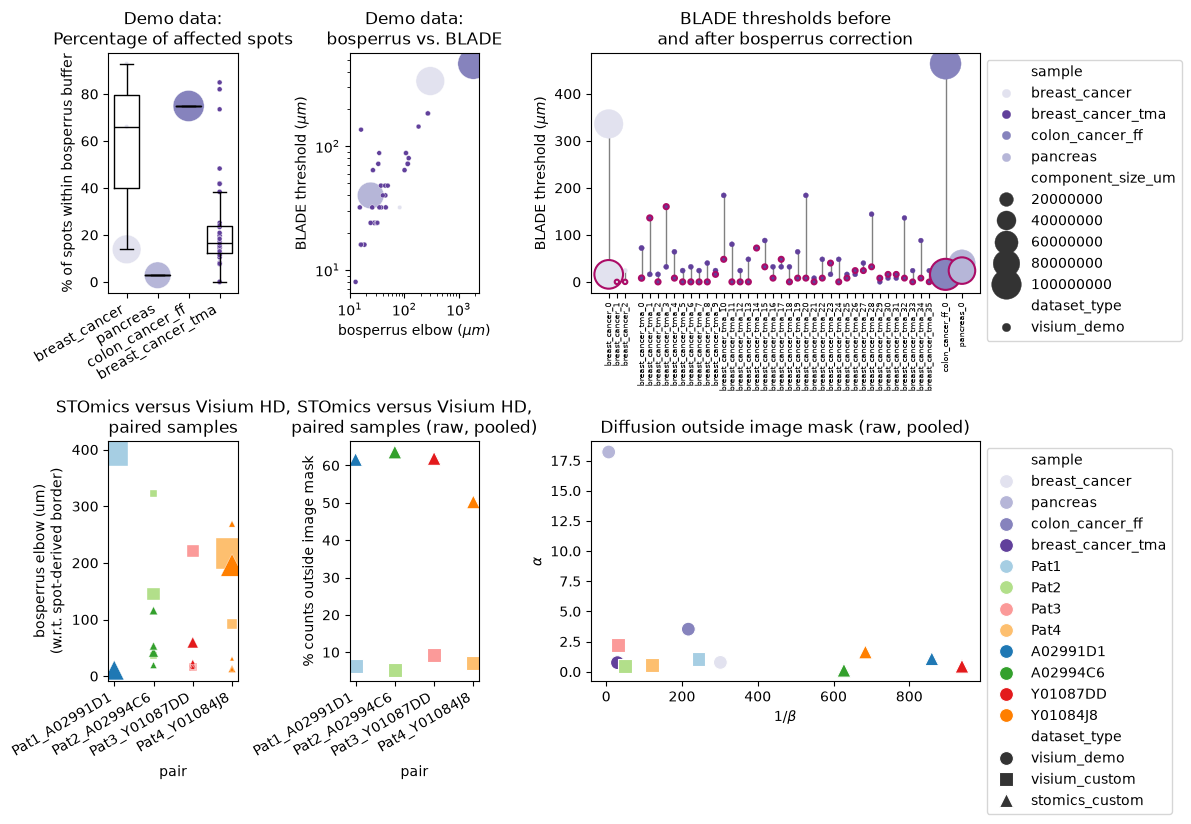

In [20]:
f, axs = plt.subplots(2, 3, figsize=(12, 8), width_ratios=[1, 1, 3])

# a: Demo data only. Which percentage of spots would need to be excluded according to bosperrus.
sns.boxplot(demo_results_df, x="sample", y="pct_affected", color="black", fill=False, showfliers=False, linewidth=1, ax=axs[0, 0])
sns.scatterplot(demo_results_df,  x="sample", y="pct_affected", style="dataset_type", hue="sample", size="component_size_um", markers=DATASET_TYPE_MARKERS, sizes=(10, 500), palette=sample_pal, ax=axs[0, 0], legend=False)
axs[0, 0].set_ylabel("% of spots within bosperrus buffer")
axs[0, 0].set_xlabel("")
axs[0, 0].set_title("Demo data:\nPercentage of affected spots")
axs[0, 0].set_xticks(axs[0, 0].get_xticks(), axs[0, 0].get_xticklabels(), rotation=30, ha="right")

# b: Demo data only. Agreement of BLADE and bosperrus.
sns.scatterplot(demo_results_df, y="blade_thresh_um", x="bsp_thresh_um", style="dataset_type", hue="sample", size="component_size_um", markers=DATASET_TYPE_MARKERS, sizes=(10, 500), palette=sample_pal, ax=axs[0, 1], legend=False)
max_val = np.max(demo_results_df[["blade_thresh_um", "bsp_thresh_um"]].values)
axs[0, 1].plot((0,max_val), (0, max_val), c="gray", ls="-")
axs[0, 1].set_title("Demo data:\nbosperrus vs. BLADE")
axs[0, 1].set_ylabel("BLADE threshold ($\\mu m$)")
axs[0, 1].set_xlabel("bosperrus elbow ($\\mu m$)")
axs[0, 1].set_yscale("log")
axs[0, 1].set_xscale("log")

# c: Demo data only. Bosperrus correction decreases BLADE identified buffer. 
for _, row in figure2_df.iterrows():
    axs[0, 2].plot([row["x_pos"], row["x_pos"]], [row["blade_thresh_um"], row["blade_thresh_corrected_um"]], color="gray", linewidth=1, zorder=0)

sns.scatterplot(data=figure2_df, x="x_pos", y="blade_thresh_um", hue="sample", style="dataset_type", markers=DATASET_TYPE_MARKERS, palette=sample_pal, sizes=(10, 500), size="component_size_um", edgecolor=None, legend=True, ax=axs[0, 2], zorder=2)
sns.scatterplot(data=figure2_df, x="x_pos", y="blade_thresh_corrected_um", hue="sample", style="dataset_type", markers=DATASET_TYPE_MARKERS, palette=sample_pal, sizes=(10, 500), size="component_size_um", edgecolor=FIT_PALETTE["Exponential Saturation Fit"], linewidth=1.5, legend=False, ax=axs[0, 2], zorder=2)

axs[0, 2].set_xticks(x_pos)
axs[0, 2].set_xticklabels(figure2_df["component_label"], rotation=90, fontsize=6)

axs[0, 2].set_xlabel("")
axs[0, 2].set_ylabel("BLADE threshold ($\\mu m$)")
axs[0, 2].set_title("BLADE thresholds before\nand after bosperrus correction")

#axs[0, 2].set_yscale("log")
sns.move_legend(axs[0, 2], "upper left", bbox_to_anchor=(1, 1))


# d: comparison of Visium HD and STOmics on paired samples via bosperrus elbows (spot-based border --
# no image mask involved, so this stays on the original per-component filtered-data pipeline). no 1:1
# matching of components possible, hence size encoding of components to somewhat facilitate comparison. 
de_size_min = part2_df["component_size_um"].min()
de_size_max = part2_df["component_size_um"].max()

sns.scatterplot(part2_df, x="pair", y="bsp_thresh_um", hue="sample", style="technology", palette=sample_pal, size="component_size_um", sizes=(10,500), ax=axs[1, 0], legend=False, size_norm=(de_size_min, de_size_max), markers=DATASET_TYPE_MARKERS, hue_order=list(sample_pal.keys()))
axs[1, 0].set_ylabel("bosperrus elbow (um)\n(w.r.t. spot-derived border)")
axs[1, 0].set_title("STOmics versus Visium HD,\npaired samples")
axs[1, 0].set_xticks(axs[1, 0].get_xticks(), axs[1, 0].get_xticklabels(), rotation=30, ha="right")

# e: comparison of Visium HD and STOmics on paired samples via percentage of RAW counts outside the
# image mask -- pooled per sample (no per-component split), whole capture area at 8um, image-only masks
# (bosperrus.quantify_diffusion_from_raw via src/utils/st_precompute.py). One point per sample.
raw_pooled_paired_df = raw_pooled_paired_df.sort_values("pair", axis=0)
sns.scatterplot(raw_pooled_paired_df, x="pair", y="perc_outside", hue="sample", style="dataset_type", palette=sample_pal, s=100, ax=axs[1, 1], legend=False, markers=DATASET_TYPE_MARKERS, hue_order=list(sample_pal.keys()))
axs[1, 1].set_ylabel("% counts outside image mask")
axs[1, 1].set_title("STOmics versus Visium HD,\npaired samples (raw, pooled)")
axs[1, 1].set_xticks(axs[1, 1].get_xticks(), axs[1, 1].get_xticklabels(), rotation=30, ha="right")


# f: comparison of Visium HD and STOmics diffusion outside of image mask via Exponential Decay model fit --
# now the same pooled raw-data fit as panel e, over all 12 samples (paired + demo). Filled marker: color=sample,
# shape=dataset_type, fixed size (no more component_size_um -- one point per sample now), black edge linewidth
# =perc_outside (wide 0.3-3.0pt range so it's actually visible).

sns.scatterplot(raw_pooled_df, x="1/beta", y="alpha", hue="sample", palette=sample_pal, s=100, style="dataset_type", ax=axs[1, 2], legend=True, markers=DATASET_TYPE_MARKERS)
sns.move_legend(axs[1, 2], "upper left", bbox_to_anchor=(1, 1))

#axs[1, 2].set_xscale("log")
#axs[1, 2].set_yscale("log")
axs[1, 2].set_ylabel("$\\alpha$")
axs[1, 2].set_xlabel("$1/\\beta$")
axs[1, 2].set_title("Diffusion outside image mask (raw, pooled)")

plt.tight_layout()
plt.show()

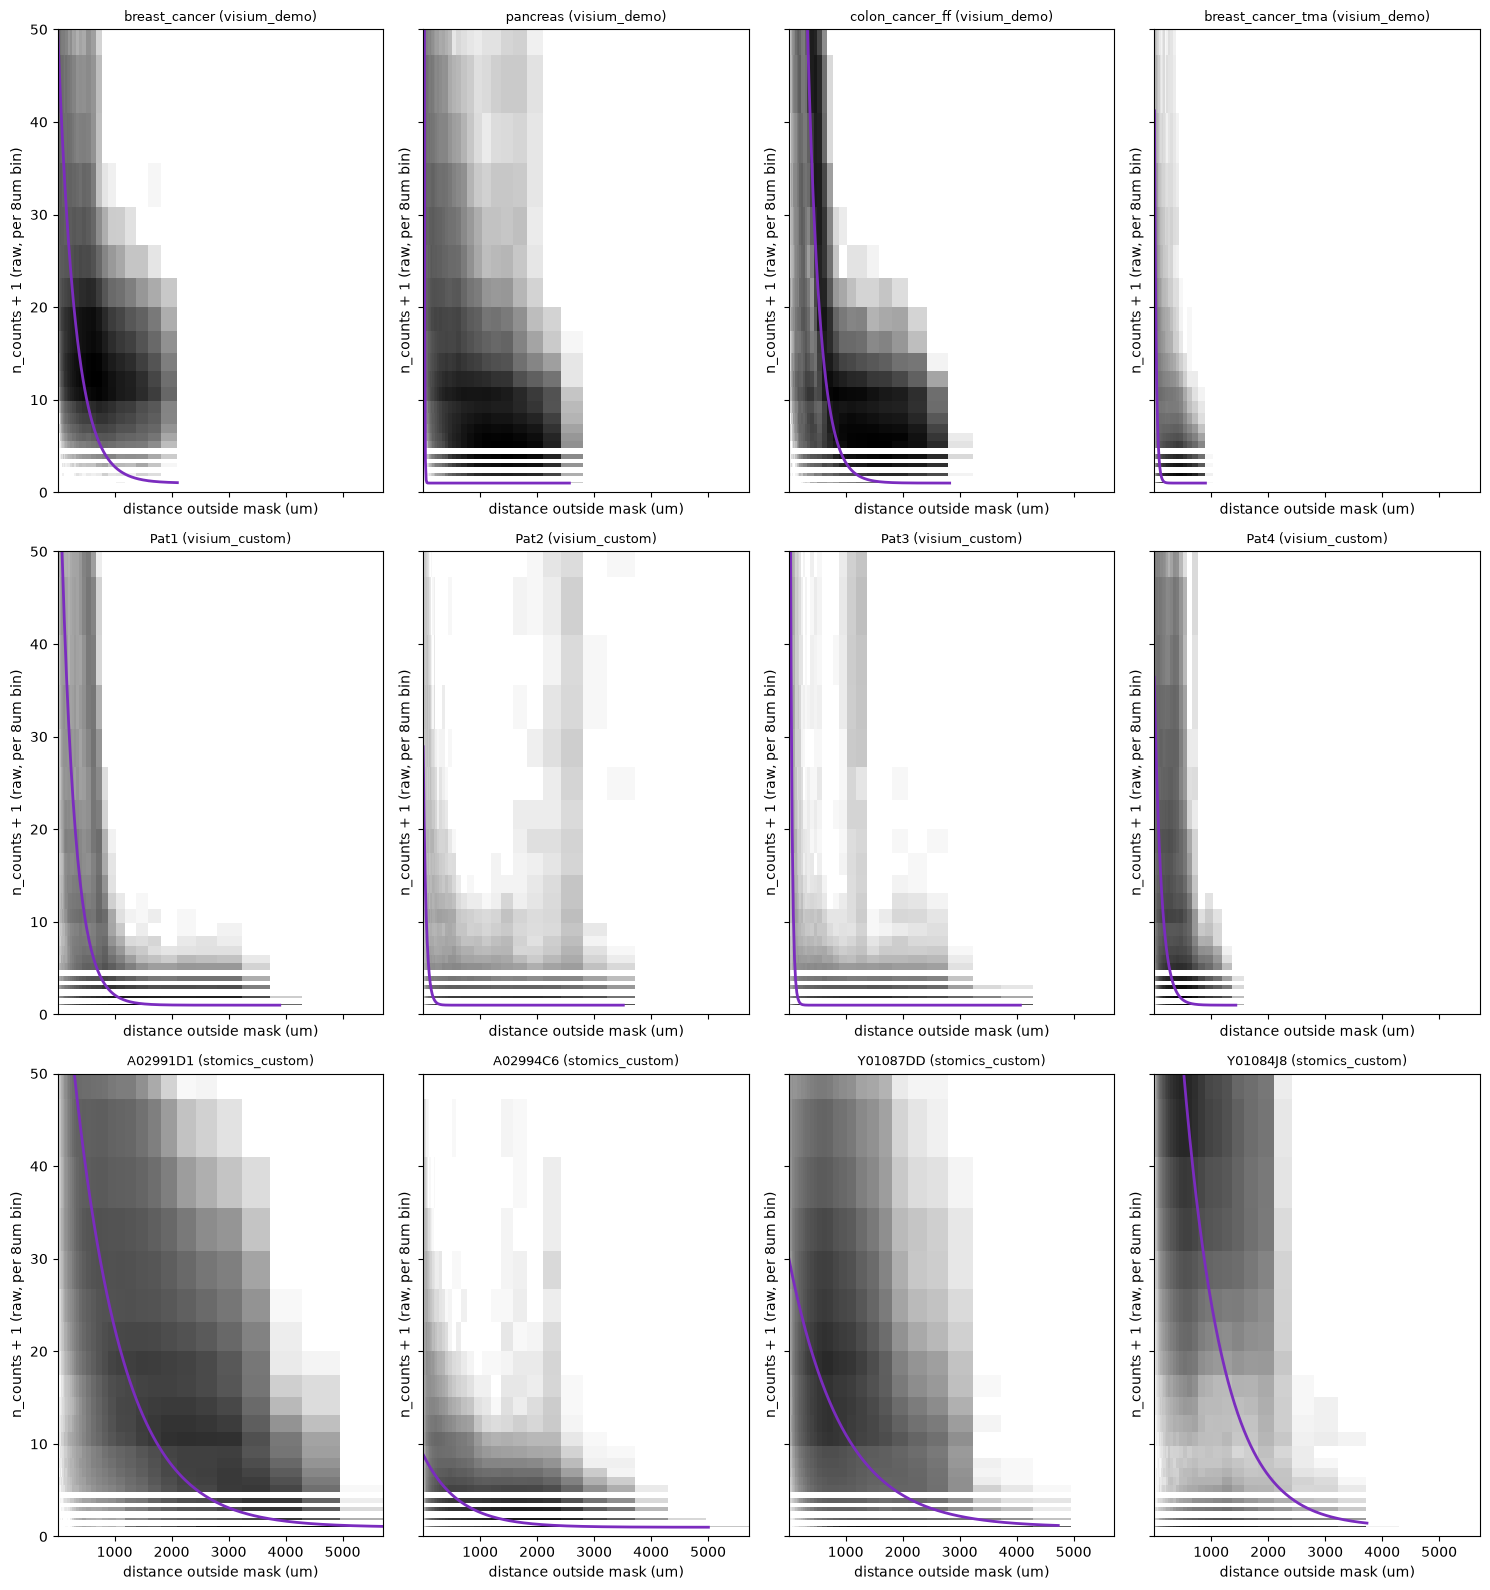

In [13]:
# One bosperrus.plot_fit per sample: the pooled diffusion fit (ConstantFit vs.
# ExponentialDecayFit on every raw 8um bin outside the mask, zero-count bins
# included -- the fit behind panels e/f) over its own 2D histogram.
#
# The curve uses the fitted per-bin amplitude a (params["exponential_decay_a"]),
# not alpha: alpha = a / bin area is the cross-resolution-comparable number, but
# the histogram shows counts per bin.
#
# Shared bin EDGES across all subplots, so a given (distance, n_counts) cell means
# the same range everywhere. n_counts+1 so zero-count bins (most bins far from the
# tissue) stay visible on a log axis.
all_distance, all_counts = [], []
for sample in raw_pooled_df["sample"]:
    pts = np.load(RESULTS_DIR / f"{sample}_diffusion_8um.npz")
    outside = pts["distance_um"] > 0
    all_distance.append(pts["distance_um"][outside])
    all_counts.append(pts["n_counts"][outside])
all_distance, all_counts = np.concatenate(all_distance), np.concatenate(all_counts) + 1

N_BINS = 60
x_edges = np.logspace(np.log10(all_distance.min()), np.log10(all_distance.max()), N_BINS + 1)
y_edges = np.logspace(np.log10(all_counts.min()), np.log10(all_counts.max()), N_BINS + 1)
del all_distance, all_counts

fig, axes = plt.subplots(3, 4, figsize=(15, 16), sharex=True, sharey=True)
for ax, (_, row) in zip(axes.flat, raw_pooled_df.iterrows()):
    pts = np.load(RESULTS_DIR / f"{row['sample']}_diffusion_8um.npz")
    distance, n_counts = pts["distance_um"], pts["n_counts"]
    outside = distance > 0

    params = row["params"]
    if row["best_fit_type"] == "Exponential Decay Fit":
        a, b = params["exponential_decay_a"], params["exponential_decay_b"]
        predict_fn = lambda d, a=a, b=b: a * np.exp(-b * d) + 1  # +1 to match the n_counts+1 shift below
    else:  # ConstantFit baseline won instead
        c = params["constant_c"] + 1
        predict_fn = lambda d, c=c: np.full_like(d, c)

    plot_fit(ax, distance[outside], n_counts[outside] + 1, predict_fn, bins=[x_edges, y_edges],
             line_kwargs={"color": FIT_PALETTE.get(row["best_fit_type"], "red")})
    #ax.set_xscale("log")
    #ax.set_yscale("log")
    ax.set_title(f"{row['sample']} ({row['dataset_type']})", fontsize=9)
    ax.set_xlabel("distance outside mask (um)")
    ax.set_ylabel("n_counts + 1 (raw, per 8um bin)")
    ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()


# Part 4: resolution ablation of the diffusion fit

Same `quantify_diffusion_from_raw` fit repeated at every bin size each technology supports
(`st_precompute.py --ablation`): Visium HD 2/8/16um; STOmics 2/4/8/10/16/25um (bin1 pooled).
If the decay is resolved, `beta` should not depend on bin size, and `alpha` (amplitude per um^2)
only weakly (averaging an exponential over a bin of size s rescales it by ~(beta*s/2)/sinh(beta*s/2)).


In [14]:
ablation_df = pd.DataFrame([json.loads(p.read_text()) for p in sorted(RESULTS_DIR.glob("*_diffusion_*um.json"))])
ablation_df = ablation_df.merge(SAMPLES[["name"]], left_on="sample", right_on="name").sort_values(["sample", "resolution_um"])

# stability relative to the 8um value used everywhere above
ref = ablation_df[ablation_df["resolution_um"] == 8.0].set_index("sample")[["alpha", "beta", "perc_counts_outside"]]
for col in ["alpha", "beta", "perc_counts_outside"]:
    ablation_df[f"{col}_rel_8um"] = ablation_df[col] / ablation_df["sample"].map(ref[col])

ablation_df.pivot_table(index=["technology", "sample"], columns="resolution_um", values="beta_rel_8um").round(2)


resolution_um                 2.0   4.0   8.0   10.0  16.0  25.0
technology sample                                               
stereo-seq A02991D1           1.00   1.0   1.0   1.0  1.00  1.00
           A02994C6           1.00   1.0   1.0   1.0  1.01  1.00
           Y01084J8           1.00   1.0   1.0   1.0  1.00  1.00
           Y01087DD           1.00   1.0   1.0   1.0  1.01  1.01
visium_hd  Pat1               1.00   NaN   1.0   NaN  1.01   NaN
           Pat2               0.98   NaN   1.0   NaN  1.09   NaN
           Pat3               1.01   NaN   1.0   NaN  0.98   NaN
           Pat4               0.99   NaN   1.0   NaN  1.02   NaN
           breast_cancer      0.99   NaN   1.0   NaN  1.06   NaN
           breast_cancer_tma  0.98   NaN   1.0   NaN  1.01   NaN
           colon_cancer_ff    1.00   NaN   1.0   NaN  1.02   NaN
           pancreas           1.07   NaN   1.0   NaN  0.88   NaN

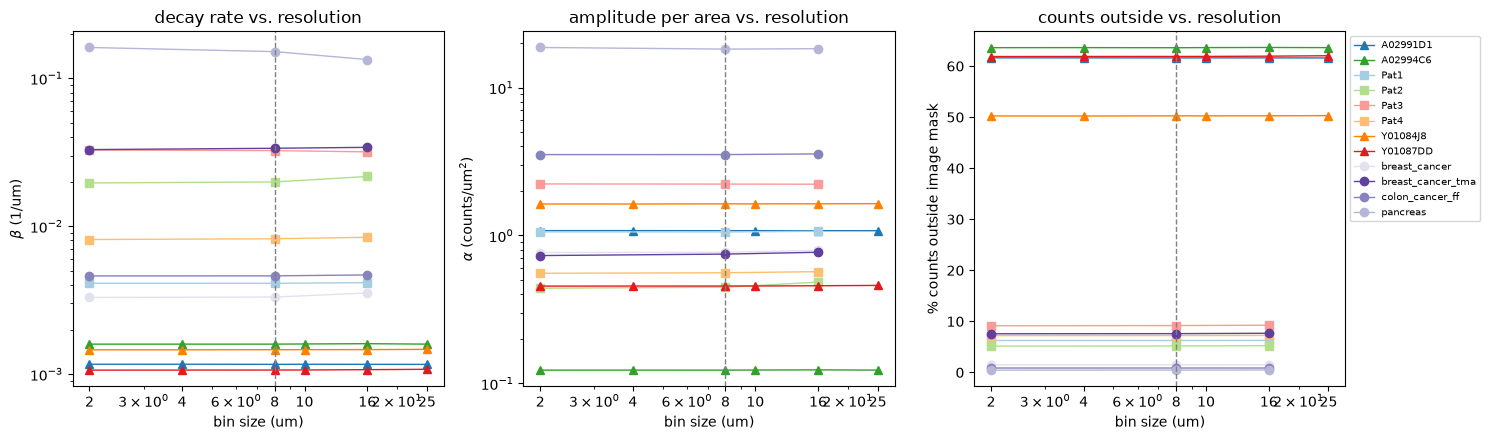

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for sample, sub in ablation_df.groupby("sample"):
    marker = DATASET_TYPE_MARKERS[sub["dataset_type"].iloc[0]]
    kwargs = dict(color=sample_pal.get(sample, "gray"), marker=marker, label=sample, lw=1)
    axs[0].plot(sub["resolution_um"], sub["beta"], **kwargs)
    axs[1].plot(sub["resolution_um"], sub["alpha"], **kwargs)
    axs[2].plot(sub["resolution_um"], sub["perc_counts_outside"], **kwargs)

for ax, ylabel in zip(axs, ["$\\beta$ (1/um)", "$\\alpha$ (counts/um$^2$)", "% counts outside image mask"]):
    ax.axvline(8, color="gray", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xticks(sorted(ablation_df["resolution_um"].unique()))
    ax.set_xticklabels([f"{r:g}" for r in sorted(ablation_df["resolution_um"].unique())])
    ax.set_xlabel("bin size (um)")
    ax.set_ylabel(ylabel)
axs[0].set_yscale("log"); axs[1].set_yscale("log")
axs[0].set_title("decay rate vs. resolution")
axs[1].set_title("amplitude per area vs. resolution")
axs[2].set_title("counts outside vs. resolution")
axs[2].legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=7)
plt.tight_layout()
plt.show()
